In [1]:
import pandas as pd

data=pd.read_csv('../data/processed/cleaned_dataset.csv')

In [2]:
score = (
    5*data["injuries_fatal"]
    + 3*data["injuries_incapacitating"]
    + 1*data["injuries_non_incapacitating"]
    + 0.5*data["injuries_reported_not_evident"]
)
data["severity_score"] = score

summary = data.groupby("most_severe_injury")["severity_score"].describe()[["count","mean","50%","75%","max"]]
summary.sort_values("mean", ascending=False)

,count,mean,50%,75%,max
most_severe_injury,,,,,
FATAL,351.0,7.202279,5.5,8.0,36.5
INCAPACITATING INJURY,6563.0,3.981639,3.0,4.0,25.0
NONINCAPACITATING INJURY,31521.0,1.436804,1.0,2.0,21.0
"REPORTED, NOT EVIDENT",16073.0,0.680054,0.5,1.0,7.5
NO INDICATION OF INJURY,154767.0,0.000000,0.0,0.0,0.0


In [3]:
data.head()

,crash_date,traffic_control_device,weather_condition,lighting_condition,first_crash_type,trafficway_type,alignment,roadway_surface_cond,road_defect,crash_type,...,injuries_reported_not_evident,injuries_no_indication,crash_hour,crash_day_of_week,crash_month,crash_datetime,crash_year,crash_day_name,any_injury,severity_score
0,07/29/2023 01:00:00 PM,TRAFFIC SIGNAL,CLEAR,DAYLIGHT,TURNING,NOT DIVIDED,STRAIGHT AND LEVEL,UNKNOWN,UNKNOWN,NO INJURY / DRIVE AWAY,...,0.0,3.0,13,7,7,2023-07-29 13:00:00,2023,Saturday,0,0.0
1,08/13/2023 12:11:00 AM,TRAFFIC SIGNAL,CLEAR,"DARKNESS, LIGHTED ROAD",TURNING,FOUR WAY,STRAIGHT AND LEVEL,DRY,NO DEFECTS,NO INJURY / DRIVE AWAY,...,0.0,2.0,0,1,8,2023-08-13 00:11:00,2023,Sunday,0,0.0
2,12/09/2021 10:30:00 AM,TRAFFIC SIGNAL,CLEAR,DAYLIGHT,REAR END,T-INTERSECTION,STRAIGHT AND LEVEL,DRY,NO DEFECTS,NO INJURY / DRIVE AWAY,...,0.0,3.0,10,5,12,2021-12-09 10:30:00,2021,Thursday,0,0.0
3,08/09/2023 07:55:00 PM,TRAFFIC SIGNAL,CLEAR,DAYLIGHT,ANGLE,FOUR WAY,STRAIGHT AND LEVEL,DRY,NO DEFECTS,INJURY AND / OR TOW DUE TO CRASH,...,0.0,0.0,19,4,8,2023-08-09 19:55:00,2023,Wednesday,1,5.0
4,08/19/2023 02:55:00 PM,TRAFFIC SIGNAL,CLEAR,DAYLIGHT,REAR END,T-INTERSECTION,STRAIGHT AND LEVEL,UNKNOWN,UNKNOWN,NO INJURY / DRIVE AWAY,...,0.0,3.0,14,7,8,2023-08-19 14:55:00,2023,Saturday,0,0.0


In [4]:
data['severity_score']

0         0.0
1         0.0
2         0.0
3         5.0
4         0.0
         ... 
209270    0.0
209271    0.0
209272    6.0
209273    1.0
209274    0.0
Name: severity_score, Length: 209275, dtype: float64

In [5]:
data["severity_score"] = (
    5*data["injuries_fatal"]
    + 3*data["injuries_incapacitating"]
    + 1*data["injuries_non_incapacitating"]
    + 0.5*data["injuries_reported_not_evident"]
)

thr = data["severity_score"].quantile(0.90)

In [6]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_absolute_error, r2_score

data = data.copy()

data["severity_score"] = (
    5*data["injuries_fatal"]
    + 3*data["injuries_incapacitating"]
    + 1*data["injuries_non_incapacitating"]
    + 0.5*data["injuries_reported_not_evident"]
)

exclude_cols = {
    "severity_score",
    "crash_type",
    "most_severe_injury",
    "any_injury",
    "injuries_total",
    "injuries_fatal",
    "injuries_incapacitating",
    "injuries_non_incapacitating",
    "injuries_reported_not_evident",
    "injuries_no_indication",
    "injuries_unknown",
    "injuries_possible",
    "injuries_minor",
    "injuries_major",
}

X = data[[c for c in data.columns if c not in exclude_cols]]
y = data["severity_score"]

cat_cols = [c for c in X.columns if X[c].dtype == "object"]
num_cols = [c for c in X.columns if c not in cat_cols]

pre = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
        ("num", "passthrough", num_cols),
    ]
)

rf = RandomForestRegressor(
    n_estimators=500,
    random_state=42,
    n_jobs=-1,
    min_samples_leaf=20,
)

pipe = Pipeline([("pre", pre), ("rf", rf)])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

pipe.fit(X_train, y_train)
pred = pipe.predict(X_test)

print("MAE:", round(mean_absolute_error(y_test, pred), 4))
print("R2 :", round(r2_score(y_test, pred), 4))

perm = permutation_importance(
    pipe, X_test, y_test, n_repeats=10, random_state=42, n_jobs=-1
)

imp = pd.DataFrame(
    {"feature": X.columns, "importance_mean": perm.importances_mean, "importance_std": perm.importances_std}
).sort_values("importance_mean", ascending=False)

imp.head(20)

KeyboardInterrupt: 

The permutation-importance results from the random-forest model suggest that crash context variables—especially num_units, damage, first_crash_type, and crash_hour—are the strongest predictors of the severity score. In contrast, factors such as weather_condition, road_defect, and several geometry/intersection indicators contribute little to the model, indicating that the severity score is driven primarily by the impact characteristics and exposure/traffic complexity rather than weather-related conditions in this dataset.

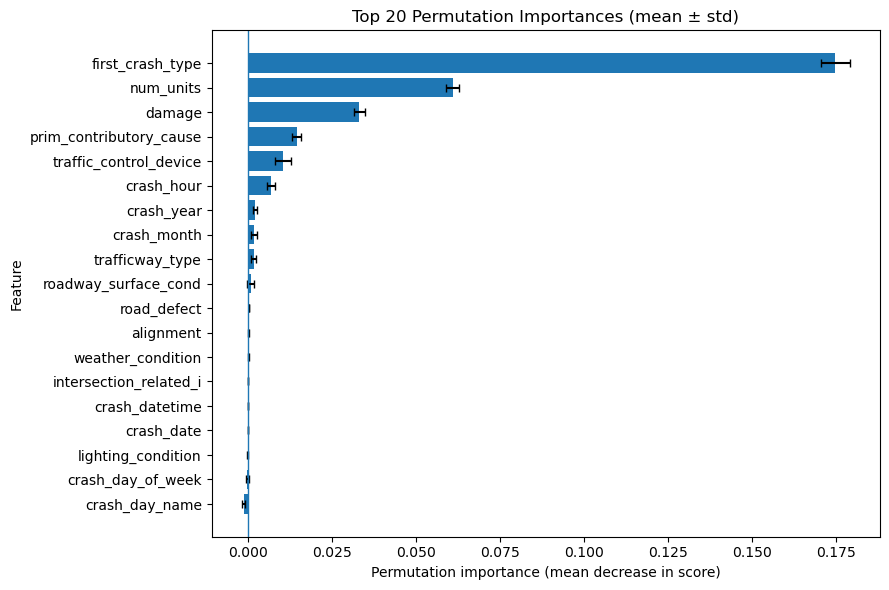

In [ ]:
import matplotlib.pyplot as plt

top_n = 20

plot_df = imp.head(top_n).copy()
plot_df = plot_df.iloc[::-1]

plt.figure(figsize=(9, 6))
plt.barh(
    plot_df["feature"],
    plot_df["importance_mean"],
    xerr=plot_df["importance_std"],
    capsize=3
)
plt.axvline(0, linewidth=1)
plt.xlabel("Permutation importance (mean decrease in score)")
plt.ylabel("Feature")
plt.title(f"Top {top_n} Permutation Importances (mean ± std)")
plt.tight_layout()
plt.show()

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.linear_model import Ridge, Lasso

In [10]:
data = pd.read_csv("../data/processed/cleaned_dataset.csv")
data.head()

,crash_date,traffic_control_device,weather_condition,lighting_condition,first_crash_type,trafficway_type,alignment,roadway_surface_cond,road_defect,crash_type,...,injuries_non_incapacitating,injuries_reported_not_evident,injuries_no_indication,crash_hour,crash_day_of_week,crash_month,crash_datetime,crash_year,crash_day_name,any_injury
0,07/29/2023 01:00:00 PM,TRAFFIC SIGNAL,CLEAR,DAYLIGHT,TURNING,NOT DIVIDED,STRAIGHT AND LEVEL,UNKNOWN,UNKNOWN,NO INJURY / DRIVE AWAY,...,0.0,0.0,3.0,13,7,7,2023-07-29 13:00:00,2023,Saturday,0
1,08/13/2023 12:11:00 AM,TRAFFIC SIGNAL,CLEAR,"DARKNESS, LIGHTED ROAD",TURNING,FOUR WAY,STRAIGHT AND LEVEL,DRY,NO DEFECTS,NO INJURY / DRIVE AWAY,...,0.0,0.0,2.0,0,1,8,2023-08-13 00:11:00,2023,Sunday,0
2,12/09/2021 10:30:00 AM,TRAFFIC SIGNAL,CLEAR,DAYLIGHT,REAR END,T-INTERSECTION,STRAIGHT AND LEVEL,DRY,NO DEFECTS,NO INJURY / DRIVE AWAY,...,0.0,0.0,3.0,10,5,12,2021-12-09 10:30:00,2021,Thursday,0
3,08/09/2023 07:55:00 PM,TRAFFIC SIGNAL,CLEAR,DAYLIGHT,ANGLE,FOUR WAY,STRAIGHT AND LEVEL,DRY,NO DEFECTS,INJURY AND / OR TOW DUE TO CRASH,...,5.0,0.0,0.0,19,4,8,2023-08-09 19:55:00,2023,Wednesday,1
4,08/19/2023 02:55:00 PM,TRAFFIC SIGNAL,CLEAR,DAYLIGHT,REAR END,T-INTERSECTION,STRAIGHT AND LEVEL,UNKNOWN,UNKNOWN,NO INJURY / DRIVE AWAY,...,0.0,0.0,3.0,14,7,8,2023-08-19 14:55:00,2023,Saturday,0


In [11]:
data = data.copy()

data["severity_score"] = (
    5 * data["injuries_fatal"]
    + 3 * data["injuries_incapacitating"]
    + 1 * data["injuries_non_incapacitating"]
    + 0.5 * data["injuries_reported_not_evident"]
)

data["severity_score"].describe()

count    209275.000000
mean          0.405588
std           1.014471
min           0.000000
25%           0.000000
50%           0.000000
75%           0.500000
max          36.500000
Name: severity_score, dtype: float64

In [12]:
exclude_cols = {
    "severity_score",
    "crash_type",
    "most_severe_injury",
    "any_injury",
    "injuries_total",
    "injuries_fatal",
    "injuries_incapacitating",
    "injuries_non_incapacitating",
    "injuries_reported_not_evident",
    "injuries_no_indication",
    "injuries_unknown",
    "injuries_possible",
    "injuries_minor",
    "injuries_major",
}

exclude_cols = {c for c in exclude_cols if c in data.columns}

X = data[[c for c in data.columns if c not in exclude_cols]].copy()
y = data["severity_score"]

print("Number of features:", X.shape[1])

Number of features: 19


In [13]:
cat_cols = [c for c in X.columns if X[c].dtype == "object"]
num_cols = [c for c in X.columns if c not in cat_cols]

for c in cat_cols:
    X[c] = X[c].fillna("Missing")

for c in num_cols:
    X[c] = X[c].fillna(X[c].median())

In [14]:
for c in cat_cols:
    top_categories = X[c].value_counts().nlargest(20).index
    X[c] = X[c].where(X[c].isin(top_categories), other="Other")

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (167420, 19)
Test size: (41855, 19)


In [16]:
pre = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
        ("num", StandardScaler(with_mean=False), num_cols),
    ]
)

In [17]:
ridge_alphas = [0.1, 1.0, 10.0, 100.0, 500.0]

ridge_results = []

for alpha in ridge_alphas:
    
    ridge_pipe = Pipeline([
        ("pre", pre),
        ("ridge", Ridge(alpha=alpha))
    ])
    
    ridge_pipe.fit(X_train, y_train)
    
    pred = ridge_pipe.predict(X_test)
    
    ridge_results.append({
        "alpha": alpha,
        "MAE": mean_absolute_error(y_test, pred),
        "R2": r2_score(y_test, pred)
    })

ridge_results_df = pd.DataFrame(ridge_results)
ridge_results_df

,alpha,MAE,R2
0,0.1,0.516178,0.127301
1,1.0,0.516164,0.127321
2,10.0,0.516106,0.127398
3,100.0,0.515955,0.127480
4,500.0,0.515991,0.126620


In [18]:
best_ridge_alpha = ridge_results_df.loc[
    ridge_results_df["R2"].idxmax(), "alpha"
]

best_ridge_pipe = Pipeline([
    ("pre", pre),
    ("ridge", Ridge(alpha=best_ridge_alpha))
])

best_ridge_pipe.fit(X_train, y_train)

ridge_pred = best_ridge_pipe.predict(X_test)

print("Best Ridge alpha:", best_ridge_alpha)
print("MAE:", round(mean_absolute_error(y_test, ridge_pred),4))
print("R2 :", round(r2_score(y_test, ridge_pred),4))

Best Ridge alpha: 100.0
MAE: 0.516
R2 : 0.1275


In [19]:
lasso_alphas = [0.0005, 0.001, 0.005, 0.01, 0.05, 0.1]

lasso_results = []

for alpha in lasso_alphas:
    
    lasso_pipe = Pipeline([
        ("pre", pre),
        ("lasso", Lasso(alpha=alpha, max_iter=10000))
    ])
    
    lasso_pipe.fit(X_train, y_train)
    
    pred = lasso_pipe.predict(X_test)
    
    lasso_results.append({
        "alpha": alpha,
        "MAE": mean_absolute_error(y_test, pred),
        "R2": r2_score(y_test, pred)
    })

lasso_results_df = pd.DataFrame(lasso_results)
lasso_results_df

,alpha,MAE,R2
0,0.0005,0.516189,0.126509
1,0.0010,0.516828,0.124816
2,0.0050,0.522906,0.113799
3,0.0100,0.535902,0.098807
4,0.0500,0.597817,0.020781
5,0.1000,0.600793,0.011947


In [20]:
best_lasso_alpha = lasso_results_df.loc[
    lasso_results_df["R2"].idxmax(), "alpha"
]

best_lasso_pipe = Pipeline([
    ("pre", pre),
    ("lasso", Lasso(alpha=best_lasso_alpha, max_iter=10000))
])

best_lasso_pipe.fit(X_train, y_train)

lasso_pred = best_lasso_pipe.predict(X_test)

print("Best Lasso alpha:", best_lasso_alpha)
print("MAE:", round(mean_absolute_error(y_test, lasso_pred),4))
print("R2 :", round(r2_score(y_test, lasso_pred),4))

Best Lasso alpha: 0.0005
MAE: 0.5162
R2 : 0.1265


In [30]:
import pandas as pd
from sklearn.metrics import mean_absolute_error, r2_score

comparison = pd.DataFrame({
    "Model": ["Ridge Regression", "Lasso Regression"],
    "MAE": [
        mean_absolute_error(y_test, ridge_pred),
        mean_absolute_error(y_test, lasso_pred)
    ],
    "R2": [
        r2_score(y_test, ridge_pred),
        r2_score(y_test, lasso_pred)
    ]
})

comparison = comparison.round(4)

comparison

,Model,MAE,R2
0,Ridge Regression,0.5160,0.1275
1,Lasso Regression,0.5162,0.1265


The two models perform very similarly, but Ridge is slightly better. Lasso is sparser but loses some performance. Ridge regression slightly outperforms Lasso regression in predictive accuracy, suggesting that retaining most predictors with small coefficients is beneficial for this dataset.

The maximum R-squared value is only 0.127, indicating that the model can only explain about 12% of the severity variation.

This may be because many important factors are not present in the data, such as driver age, seatbelt use, and medical response time.

Therefore, crash severity is influenced by many unobserved factors.

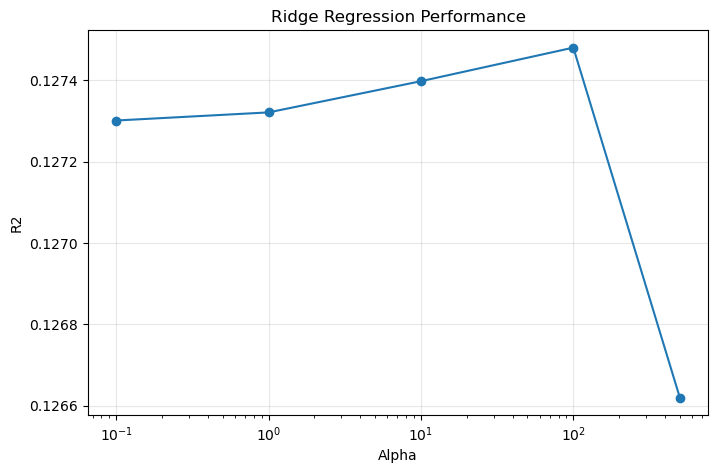

In [21]:
plt.figure(figsize=(8,5))

plt.plot(ridge_results_df["alpha"], ridge_results_df["R2"], marker="o")

plt.xscale("log")
plt.xlabel("Alpha")
plt.ylabel("R2")
plt.title("Ridge Regression Performance")

plt.grid(alpha=0.3)

plt.show()

The peak appears when alpha=100;
A moderate level of regularization improves prediction performance by reducing overfitting.

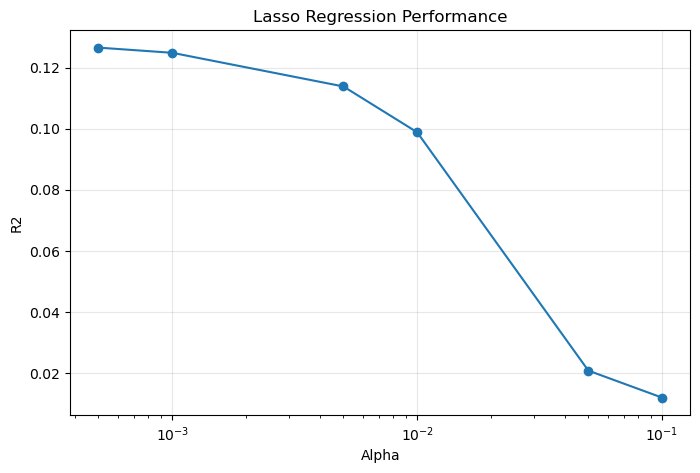

In [22]:
plt.figure(figsize=(8,5))

plt.plot(lasso_results_df["alpha"], lasso_results_df["R2"], marker="o")

plt.xscale("log")
plt.xlabel("Alpha")
plt.ylabel("R2")
plt.title("Lasso Regression Performance")

plt.grid(alpha=0.3)

plt.show()

As alpha increases, R-squared decreases rapidly, indicating that Lasso's strong feature selection leads to a loss of model information. Strong L1 regularization removes too many predictors and significantly reduces predictive performance.

In [23]:
feature_names = best_lasso_pipe.named_steps["pre"].get_feature_names_out()

lasso_coef = best_lasso_pipe.named_steps["lasso"].coef_

coef_df = pd.DataFrame({
    "feature": feature_names,
    "coef": lasso_coef
})

coef_df = coef_df[coef_df["coef"] != 0]

coef_df["abs_coef"] = coef_df["coef"].abs()

coef_df = coef_df.sort_values("abs_coef", ascending=False)

coef_df.head(20)

,feature,coef,abs_coef
67,cat__first_crash_type_PEDESTRIAN,0.862677,0.862677
66,cat__first_crash_type_PEDALCYCLIST,0.508955,0.508955
139,cat__prim_contributory_cause_UNDER THE INFLUEN...,0.379307,0.379307
65,cat__first_crash_type_PARKED MOTOR VEHICLE,-0.367864,0.367864
73,cat__first_crash_type_SIDESWIPE SAME DIRECTION,-0.314600,0.314600
60,cat__first_crash_type_FIXED OBJECT,0.292982,0.292982
68,cat__first_crash_type_REAR END,-0.247406,0.247406
123,cat__prim_contributory_cause_DISREGARDING TRAF...,0.247337,0.247337
120,"cat__damage_OVER $1,500",0.208190,0.208190
69,cat__first_crash_type_REAR TO FRONT,-0.167589,0.167589


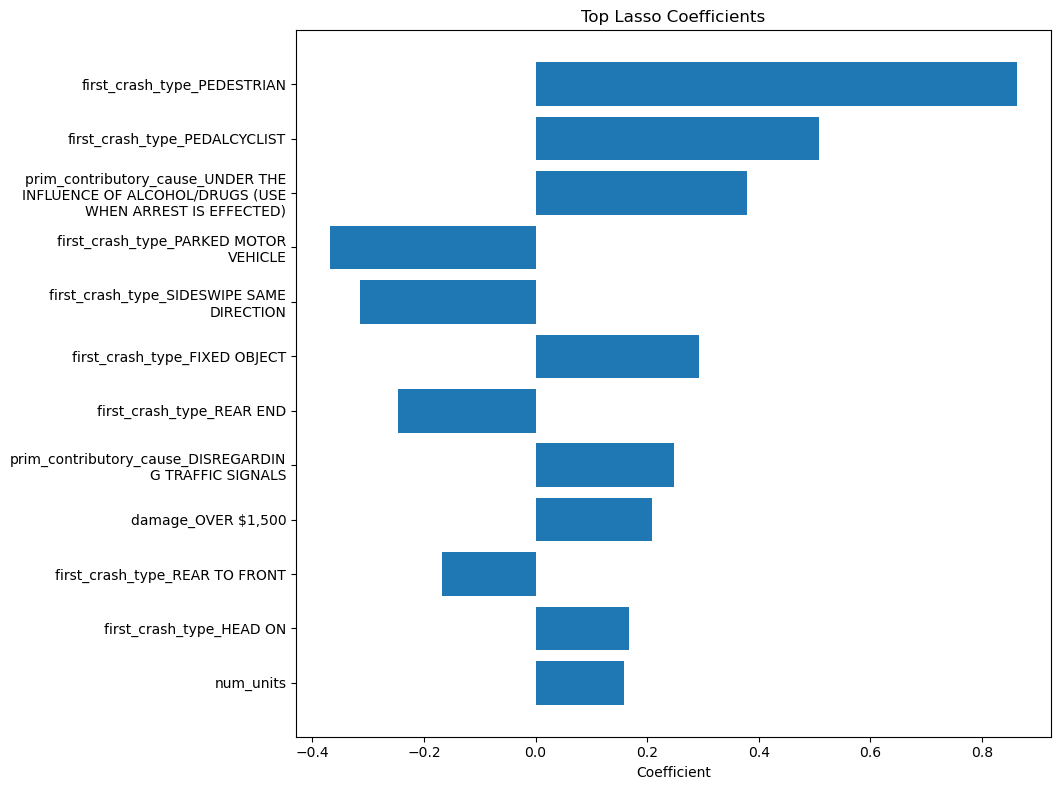

In [29]:
import textwrap
import matplotlib.pyplot as plt

top_n = 12

plot_df = coef_df.sort_values("abs_coef", ascending=False).head(top_n).copy()
plot_df = plot_df.iloc[::-1]

plot_df["feature"] = plot_df["feature"].str.replace("cat__", "", regex=False)
plot_df["feature"] = plot_df["feature"].str.replace("num__", "", regex=False)

plot_df["feature_wrapped"] = plot_df["feature"].apply(
    lambda x: "\n".join(textwrap.wrap(x, width=35))
)

plt.figure(figsize=(14, 8))
plt.barh(plot_df["feature_wrapped"], plot_df["coef"])

plt.xlabel("Coefficient")
plt.title("Top Lasso Coefficients")
plt.tight_layout()
plt.subplots_adjust(left=0.45) 
plt.show()

Crashes involving pedestrians or cyclists tend to result in higher severity.

Driving under the influence is strongly associated with higher crash severity.

Traffic signal violations increase crash severity.

Crashes involving more vehicles tend to be more severe.

PARKED MOTOR VEHICLE, SIDESWIPE SAME DIRECTION. These crash types are associated with relatively lower severity.